✅ Image loaded successfully! Shape: (640, 960)


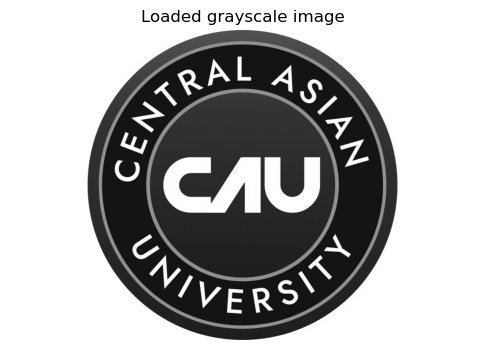

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("D:/Wallpers/CAU.jpg", cv2.IMREAD_GRAYSCALE)

# Check if image loaded successfully
if image is None:
    print("❌ Image not found! Check your path.")
else:
    print("✅ Image loaded successfully! Shape:", image.shape)
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap="gray")
    plt.title("Loaded grayscale image")
    plt.axis("off")
    plt.show()

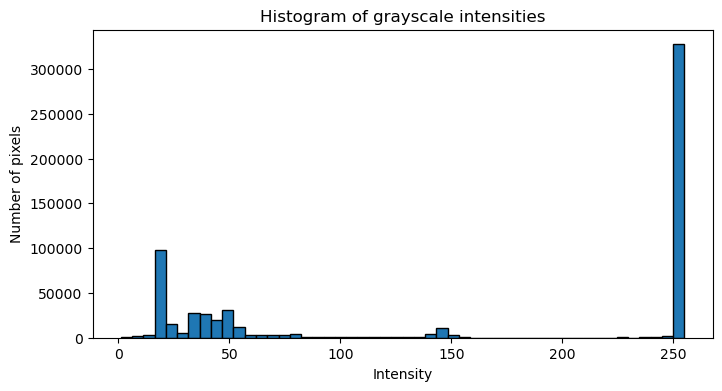

In [2]:
plt.figure(figsize=(8, 4))
plt.hist(image.ravel(), bins=50, edgecolor="black")
plt.title("Histogram of grayscale intensities")
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.show()

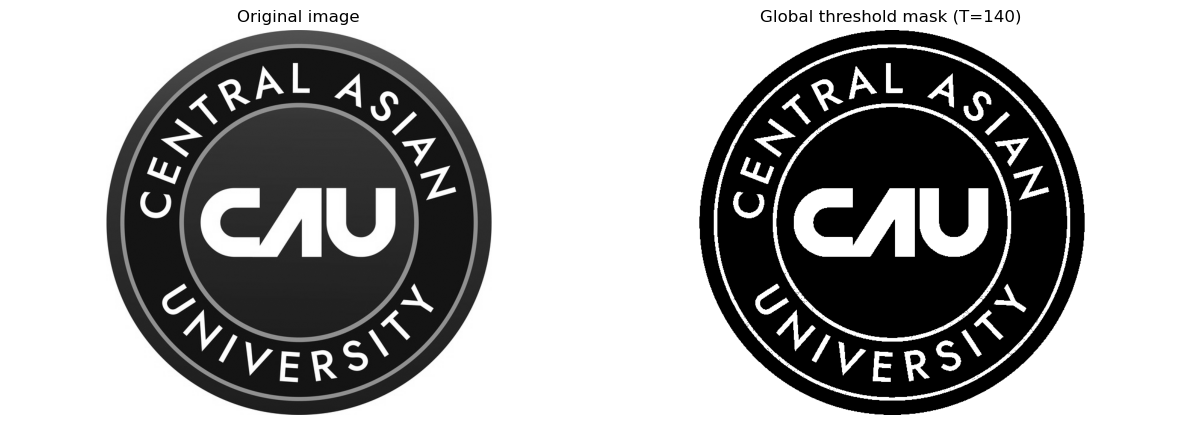

In [3]:
def global_threshold(image, T):
    return (image >= T).astype(np.uint8)

T = 140
mask_global = global_threshold(image, T)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(mask_global, cmap="gray")
axes[1].set_title(f"Global threshold mask (T={T})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

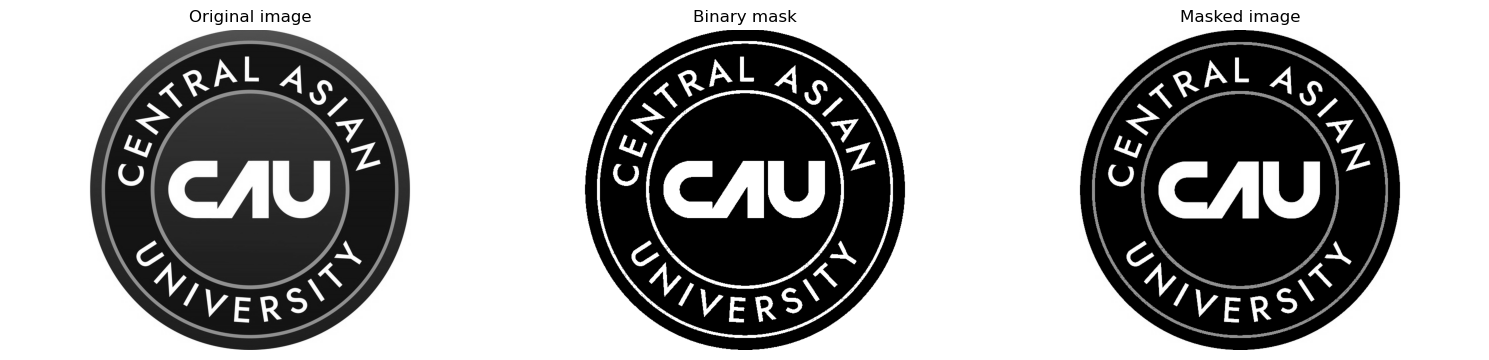

In [4]:
masked_image = image * mask_global

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(mask_global, cmap="gray")
axes[1].set_title("Binary mask")
axes[1].axis("off")

axes[2].imshow(masked_image, cmap="gray")
axes[2].set_title("Masked image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

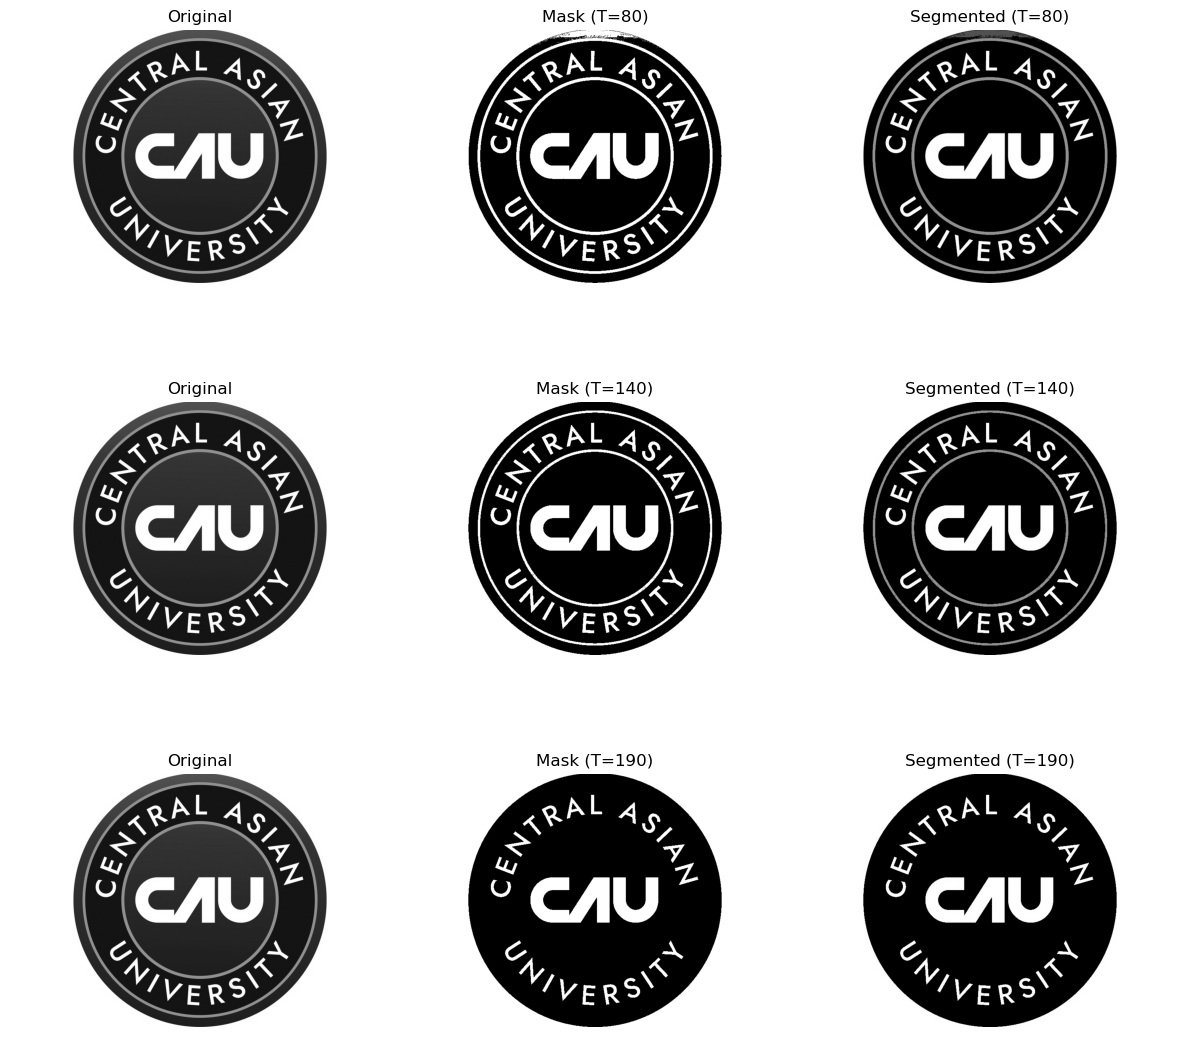

In [5]:
def segment_and_mask(image, threshold):
    mask = (image >= threshold).astype(np.uint8)
    segmented = image * mask
    return mask, segmented

test_thresholds = [80, 140, 190]

fig, axes = plt.subplots(len(test_thresholds), 3, figsize=(12, 12))

for i, thr in enumerate(test_thresholds):
    mask, segmented = segment_and_mask(image, thr)

    axes[i, 0].imshow(image, cmap="gray")
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"Mask (T={thr})")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(segmented, cmap="gray")
    axes[i, 2].set_title(f"Segmented (T={thr})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [6]:
def convolve2d(image, kernel):
    image = image.astype(np.float32)
    kernel = np.array(kernel, dtype=np.float32)

    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="edge")
    out = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)

    return out

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

Gx = convolve2d(image, sobel_x)
Gy = convolve2d(image, sobel_y)
gradient_magnitude = np.sqrt(Gx**2 + Gy**2)


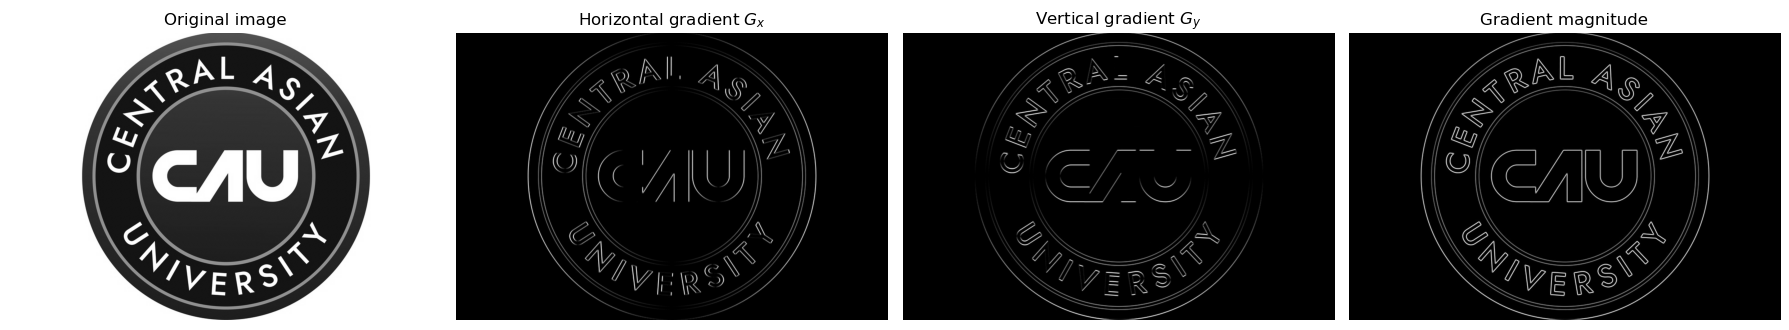

In [8]:
# Step 1: Compute gradients using Sobel filters
image_float = image.astype(np.float32)

Gx = cv2.Sobel(image_float, cv2.CV_32F, 1, 0, ksize=3)  # Horizontal gradient
Gy = cv2.Sobel(image_float, cv2.CV_32F, 0, 1, ksize=3)  # Vertical gradient

# Step 2: Compute gradient magnitude
gradient_magnitude = np.sqrt(Gx**2 + Gy**2)

# Step 3: Normalize for display (0-255)
Gx_display = cv2.normalize(np.abs(Gx), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
Gy_display = cv2.normalize(np.abs(Gy), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
grad_display = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Step 4: Visualize
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(Gx_display, cmap="gray")
axes[1].set_title("Horizontal gradient $G_x$")
axes[1].axis("off")

axes[2].imshow(Gy_display, cmap="gray")
axes[2].set_title("Vertical gradient $G_y$")
axes[2].axis("off")

axes[3].imshow(grad_display, cmap="gray")
axes[3].set_title("Gradient magnitude")
axes[3].axis("off")

plt.tight_layout()
plt.show()

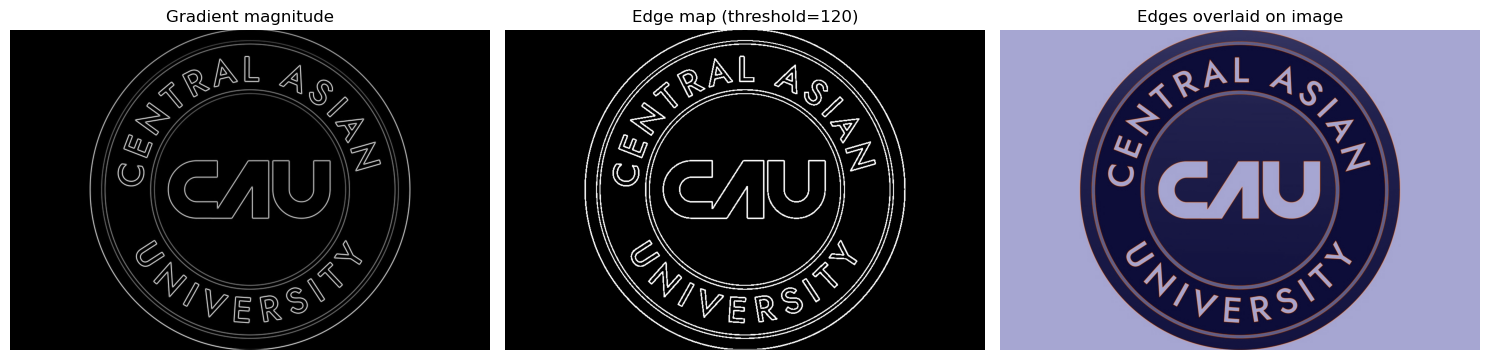

In [9]:
edge_threshold = 120
edges = (gradient_magnitude >= edge_threshold).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gradient_magnitude, cmap="gray")
axes[0].set_title("Gradient magnitude")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title(f"Edge map (threshold={edge_threshold})")
axes[1].axis("off")

axes[2].imshow(image, cmap="gray")
axes[2].imshow(edges, cmap="jet", alpha=0.35)
axes[2].set_title("Edges overlaid on image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

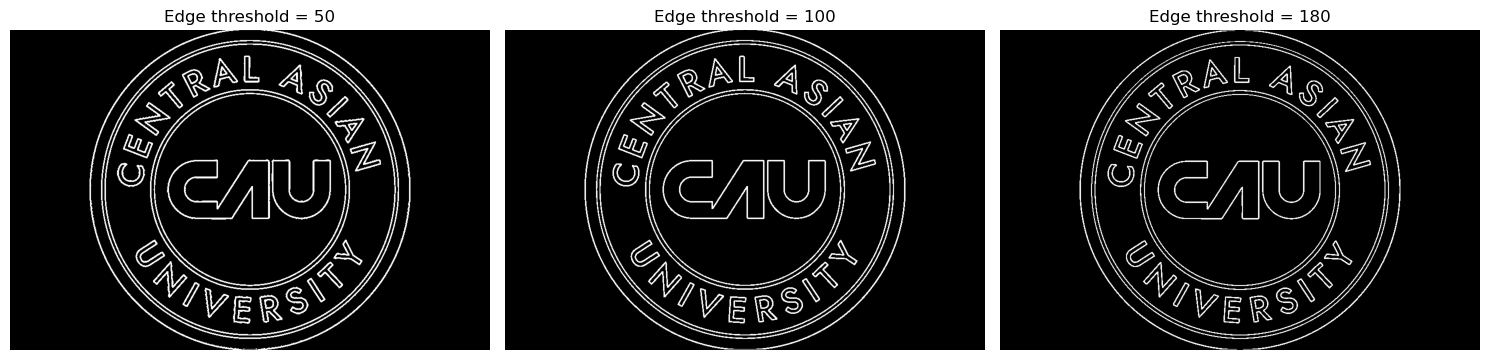

In [10]:
edge_thresholds = [50, 100, 180]

fig, axes = plt.subplots(1, len(edge_thresholds), figsize=(15, 5))

for ax, thr in zip(axes, edge_thresholds):
    e = (gradient_magnitude >= thr).astype(np.uint8)
    ax.imshow(e, cmap="gray")
    ax.set_title(f"Edge threshold = {thr}")
    ax.axis("off")

plt.tight_layout()
plt.show()
     


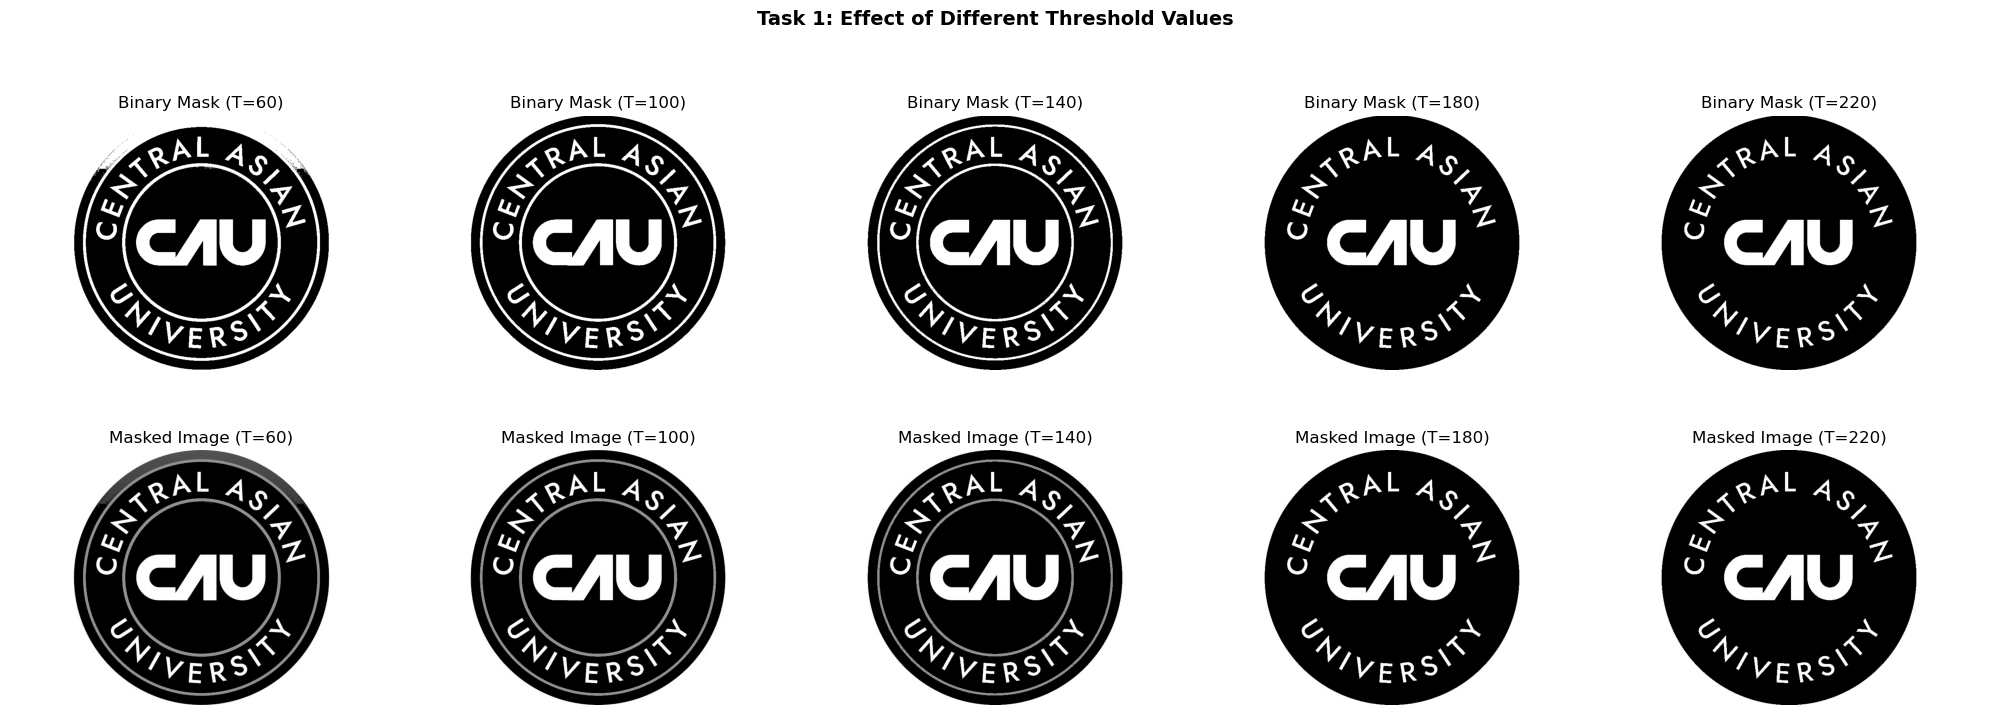

=== Observations ===
T=60:  Very low threshold — almost all pixels kept. Background and foreground barely separated.
T=100: More background removed. Brighter regions start to stand out.
T=140: Good balance — main bright objects visible, dark background mostly removed.
T=180: Only bright regions remain. Fine details may be lost.
T=220: Very strict — only the brightest pixels survive. Most image is black.

✅ Best threshold: T=140 gives the best separation between object and background.


In [11]:
# Task 1: Try Different Threshold Values
threshold_values = [60, 100, 140, 180, 220]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, T in enumerate(threshold_values):
    # Generate binary mask
    mask = global_threshold(image, T)
    
    # Top row: binary masks
    axes[0][i].imshow(mask, cmap="gray")
    axes[0][i].set_title(f"Binary Mask (T={T})")
    axes[0][i].axis("off")
    
    # Bottom row: masked images
    masked = image * mask
    axes[1][i].imshow(masked, cmap="gray")
    axes[1][i].set_title(f"Masked Image (T={T})")
    axes[1][i].axis("off")

plt.suptitle("Task 1: Effect of Different Threshold Values", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Comments on observations
comments = {
    60:  "T=60:  Very low threshold — almost all pixels kept. Background and foreground barely separated.",
    100: "T=100: More background removed. Brighter regions start to stand out.",
    140: "T=140: Good balance — main bright objects visible, dark background mostly removed.",
    180: "T=180: Only bright regions remain. Fine details may be lost.",
    220: "T=220: Very strict — only the brightest pixels survive. Most image is black."
}

print("=== Observations ===")
for T, comment in comments.items():
    print(comment)

print("\n✅ Best threshold: T=140 gives the best separation between object and background.")

Running my_threshold... (may take a moment due to loops)
✅ Results match global_threshold: True


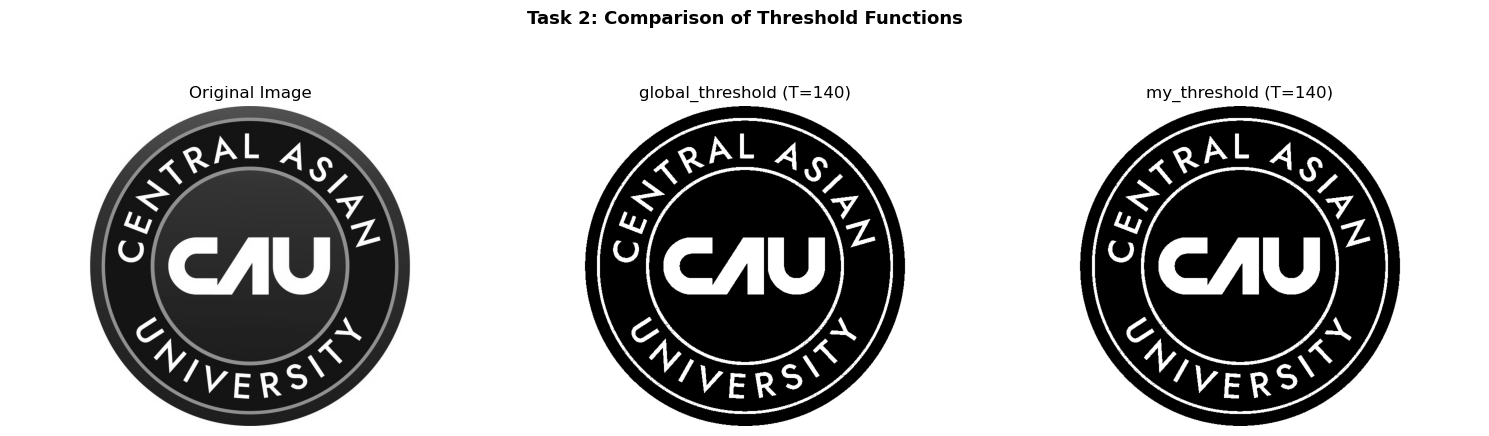

In [12]:
# Task 2: Build Your Own Segmentation Function

def my_threshold(image, T):
    # Create an empty mask of zeros with same shape as image
    mask = np.zeros(image.shape, dtype=np.uint8)
    
    # Loop through every pixel using nested for loops
    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            if image[row, col] >= T:
                mask[row, col] = 1  # Foreground
            else:
                mask[row, col] = 0  # Background
    return mask

# Test with T=140
T = 140
print("Running my_threshold... (may take a moment due to loops)")
my_mask = my_threshold(image, T)

# Compare with original global_threshold
original_mask = global_threshold(image, T)

# Check if results are identical
match = np.array_equal(my_mask, original_mask)
print(f"✅ Results match global_threshold: {match}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(original_mask, cmap="gray")
axes[1].set_title(f"global_threshold (T={T})")
axes[1].axis("off")

axes[2].imshow(my_mask, cmap="gray")
axes[2].set_title(f"my_threshold (T={T})")
axes[2].axis("off")

plt.suptitle("Task 2: Comparison of Threshold Functions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

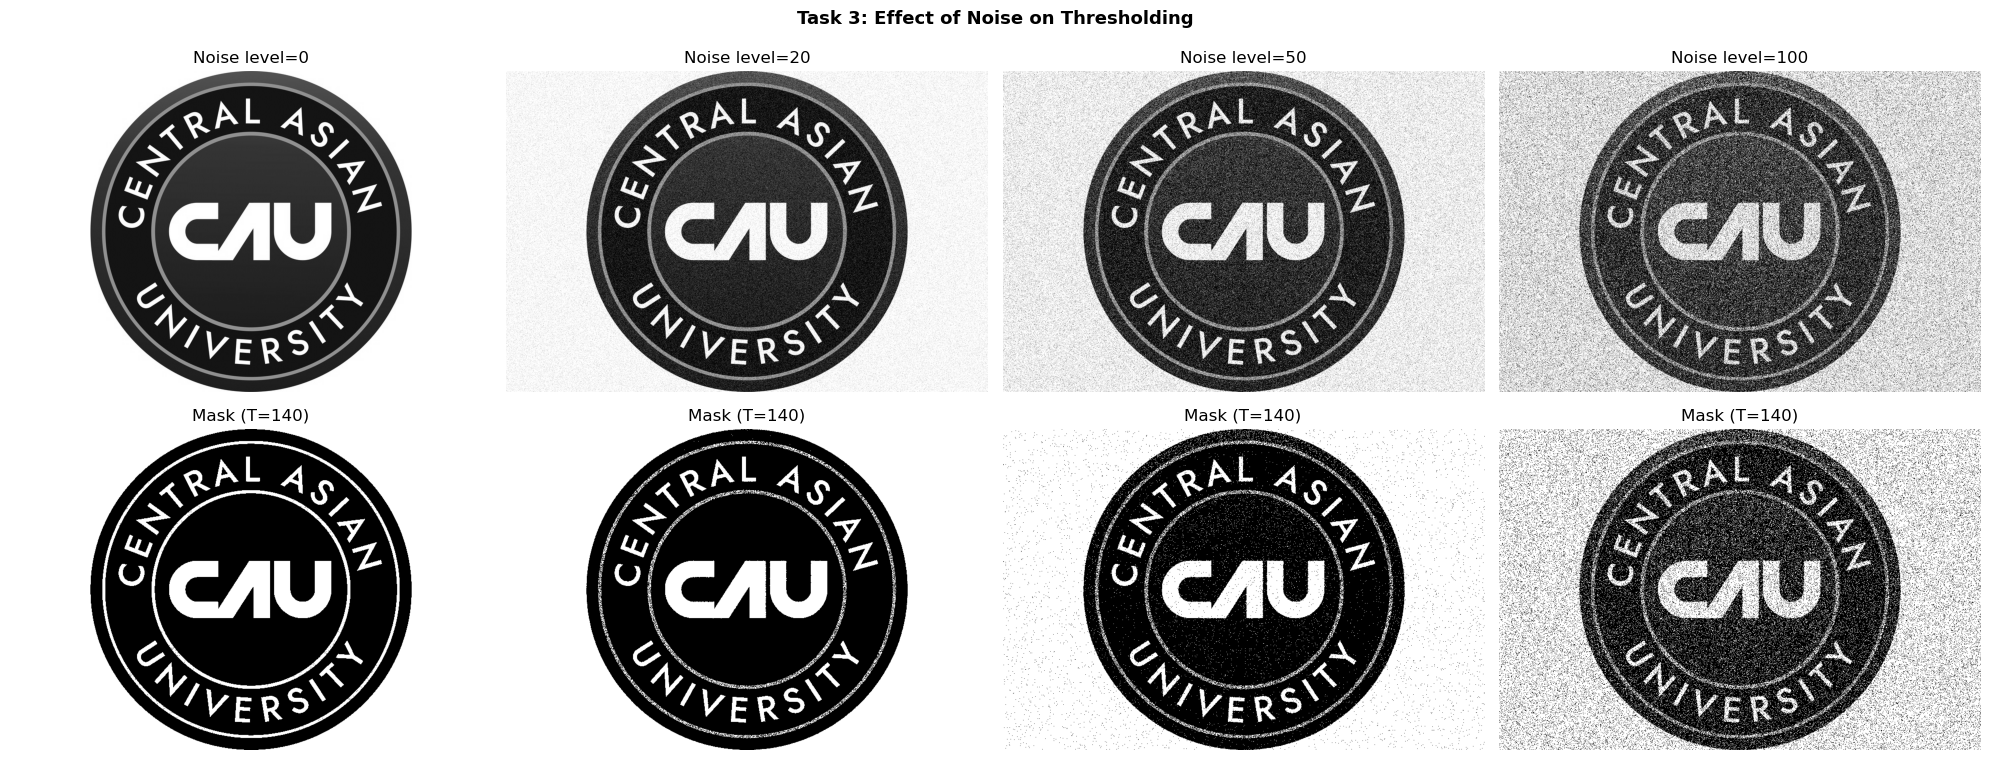

=== Task 3 Observations ===
Q1: What happens to the mask?
    → More noise = more scattered white/black pixels (salt & pepper effect)
Q2: Does the same threshold still work?
    → At low noise (20): still works well.
    → At high noise (50-100): mask becomes unreliable, many false pixels.
Q3: What could you do to improve the result?
    → Apply a blur/smoothing filter BEFORE thresholding to reduce noise.

=== Challenge 1: Otsu's Method ===
Otsu's automatic threshold: T = 146.0
Our manual threshold:       T = 140


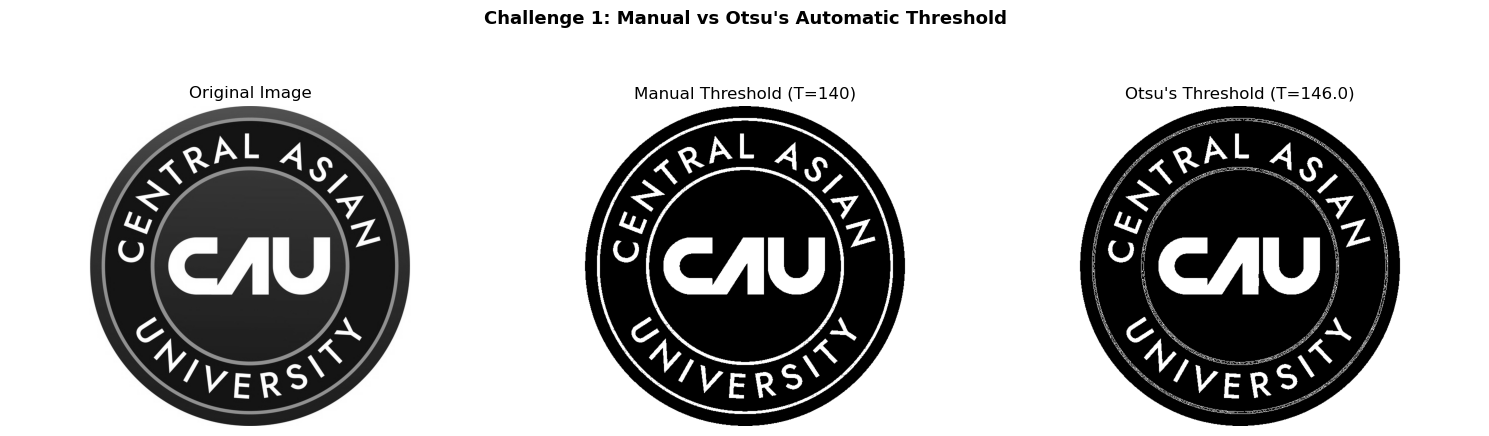

✅ Pixel agreement between manual and Otsu: 98.4%


In [13]:
# ============================================================
# TASK 3: Noise Challenge
# ============================================================

def add_noise(image, noise_level):
    """Add Gaussian noise to an image"""
    noise = np.random.normal(loc=0, scale=noise_level, size=image.shape)
    noisy = np.clip(image.astype(np.float32) + noise, 0, 255)
    return noisy.astype(np.uint8)

# Test with different noise levels
noise_levels = [0, 20, 50, 100]
T = 140

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, noise_level in enumerate(noise_levels):
    noisy_image = add_noise(image, noise_level)
    mask = global_threshold(noisy_image, T)

    # Top row: noisy images
    axes[0][i].imshow(noisy_image, cmap="gray")
    axes[0][i].set_title(f"Noise level={noise_level}")
    axes[0][i].axis("off")

    # Bottom row: masks
    axes[1][i].imshow(mask, cmap="gray")
    axes[1][i].set_title(f"Mask (T={T})")
    axes[1][i].axis("off")

plt.suptitle("Task 3: Effect of Noise on Thresholding", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Answers to questions
print("=== Task 3 Observations ===")
print("Q1: What happens to the mask?")
print("    → More noise = more scattered white/black pixels (salt & pepper effect)")
print("Q2: Does the same threshold still work?")
print("    → At low noise (20): still works well.")
print("    → At high noise (50-100): mask becomes unreliable, many false pixels.")
print("Q3: What could you do to improve the result?")
print("    → Apply a blur/smoothing filter BEFORE thresholding to reduce noise.\n")


# ============================================================
# CHALLENGE 1: Automatic Threshold Selection (Otsu's Method)
# ============================================================

from skimage.filters import threshold_otsu

# Compute Otsu's threshold automatically
otsu_T = threshold_otsu(image)
print(f"=== Challenge 1: Otsu's Method ===")
print(f"Otsu's automatic threshold: T = {otsu_T:.1f}")
print(f"Our manual threshold:       T = 140")

# Generate masks
mask_manual = global_threshold(image, 140)
mask_otsu   = global_threshold(image, int(otsu_T))

# Compare visually
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask_manual, cmap="gray")
axes[1].set_title("Manual Threshold (T=140)")
axes[1].axis("off")

axes[2].imshow(mask_otsu, cmap="gray")
axes[2].set_title(f"Otsu's Threshold (T={otsu_T:.1f})")
axes[2].axis("off")

plt.suptitle("Challenge 1: Manual vs Otsu's Automatic Threshold", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Pixel agreement
agreement = np.mean(mask_manual == mask_otsu) * 100
print(f"✅ Pixel agreement between manual and Otsu: {agreement:.1f}%")

=== Challenge 2: White Pixel Count ===
Image size:             640 x 960 pixels
Total pixels:           614400
Foreground pixels (1):  351758
Background pixels (0):  262642
Foreground percentage:  57.25%
Background percentage:  42.75%


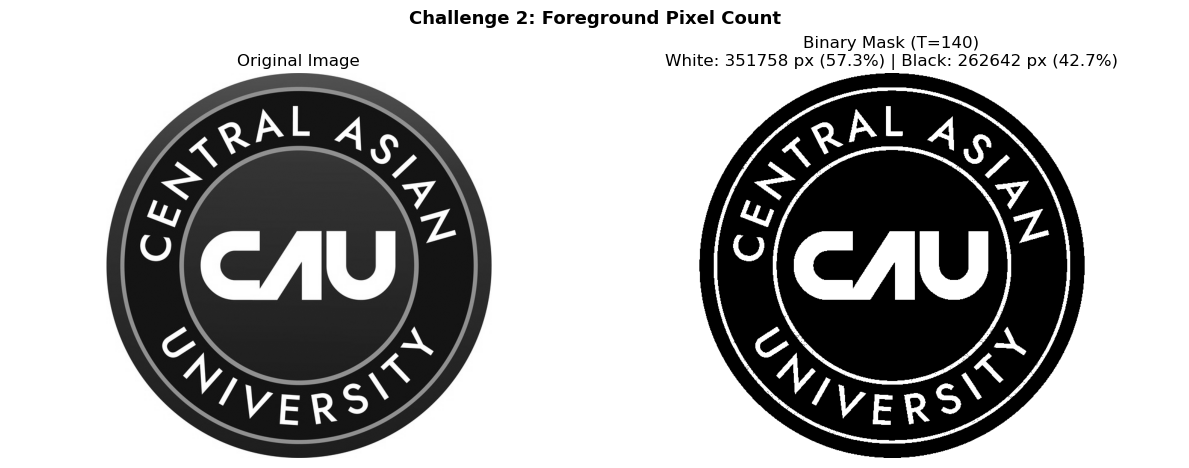

In [15]:
# ============================================================
# CHALLENGE 2: Count the Number of White Pixels
# ============================================================

T = 140
mask_global = global_threshold(image, T)

# Count foreground pixels (where mask == 1)
white_pixels = np.sum(mask_global == 1)

# Total pixels in image
total_pixels = image.shape[0] * image.shape[1]

# Percentage of image selected
percentage = (white_pixels / total_pixels) * 100

# Print results
print("=== Challenge 2: White Pixel Count ===")
print(f"Image size:             {image.shape[0]} x {image.shape[1]} pixels")
print(f"Total pixels:           {total_pixels}")
print(f"Foreground pixels (1):  {white_pixels}")
print(f"Background pixels (0):  {total_pixels - white_pixels}")
print(f"Foreground percentage:  {percentage:.2f}%")
print(f"Background percentage:  {100 - percentage:.2f}%")

# Visualize with annotation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask_global, cmap="gray")
axes[1].set_title(f"Binary Mask (T={T})\nWhite: {white_pixels} px ({percentage:.1f}%) | Black: {total_pixels - white_pixels} px ({100-percentage:.1f}%)")
axes[1].axis("off")

plt.suptitle("Challenge 2: Foreground Pixel Count", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

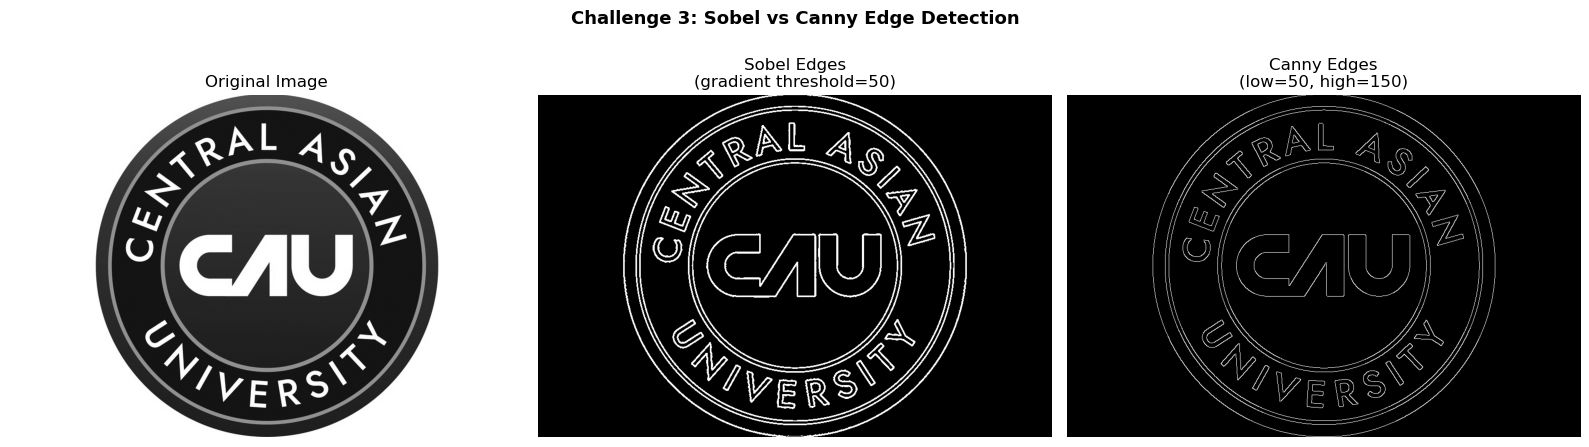

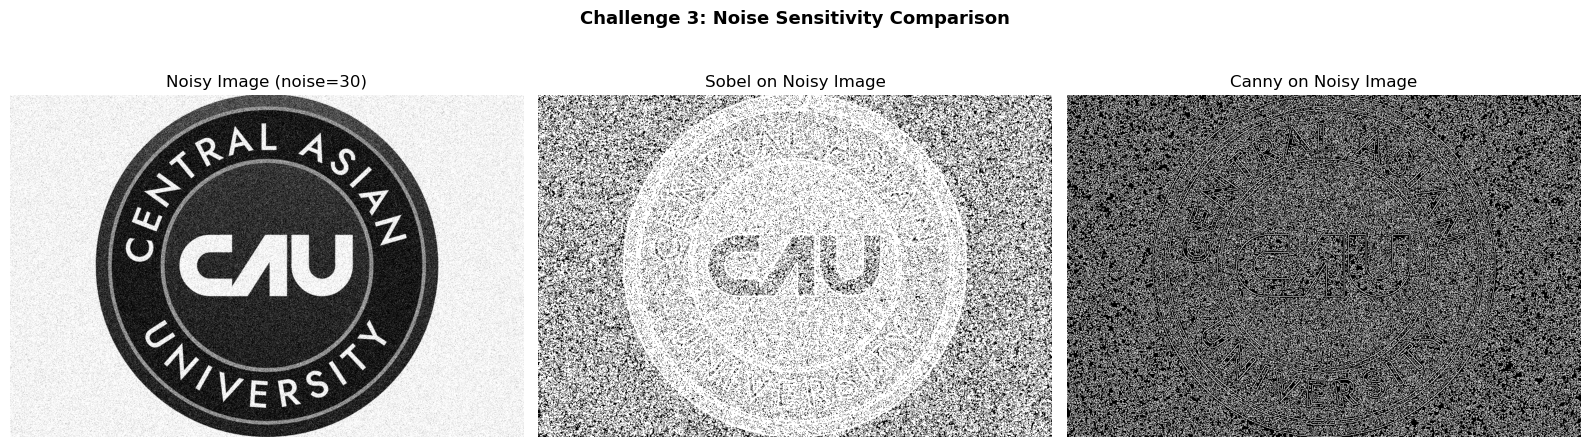

=== Challenge 3: Answers ===
Q1: Which method gives cleaner edges?
    Canny gives much cleaner, thinner, well-defined edges.
    Sobel produces thicker edges and requires manual thresholding.

Q2: Which one is more sensitive to noise?
    Sobel is MORE sensitive to noise — noise creates many false edges.
    Canny is MORE robust — it uses Gaussian smoothing internally
    to suppress noise before detecting edges.


In [16]:
# ============================================================
# CHALLENGE 3: Edge Detection Comparison - Sobel vs Canny
# ============================================================

# --- SOBEL EDGE DETECTION ---
image_float = image.astype(np.float32)

Gx = cv2.Sobel(image_float, cv2.CV_32F, 1, 0, ksize=3)
Gy = cv2.Sobel(image_float, cv2.CV_32F, 0, 1, ksize=3)
gradient_magnitude = np.sqrt(Gx**2 + Gy**2)

# Threshold the gradient magnitude to get Sobel edge map
sobel_threshold = 50
sobel_edges = (gradient_magnitude >= sobel_threshold).astype(np.uint8) * 255

# --- CANNY EDGE DETECTION ---
# Canny needs uint8 image, two thresholds (low, high)
canny_edges = cv2.Canny(image, 50, 150)

# --- VISUALIZE COMPARISON ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(sobel_edges, cmap="gray")
axes[1].set_title(f"Sobel Edges\n(gradient threshold={sobel_threshold})")
axes[1].axis("off")

axes[2].imshow(canny_edges, cmap="gray")
axes[2].set_title("Canny Edges\n(low=50, high=150)")
axes[2].axis("off")

plt.suptitle("Challenge 3: Sobel vs Canny Edge Detection", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- NOISE SENSITIVITY TEST ---
noisy_image = add_noise(image, noise_level=30)

sobel_noisy_float = noisy_image.astype(np.float32)
Gx_n = cv2.Sobel(sobel_noisy_float, cv2.CV_32F, 1, 0, ksize=3)
Gy_n = cv2.Sobel(sobel_noisy_float, cv2.CV_32F, 0, 1, ksize=3)
sobel_noisy_edges = (np.sqrt(Gx_n**2 + Gy_n**2) >= sobel_threshold).astype(np.uint8) * 255

canny_noisy_edges = cv2.Canny(noisy_image, 50, 150)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(noisy_image, cmap="gray")
axes[0].set_title("Noisy Image (noise=30)")
axes[0].axis("off")

axes[1].imshow(sobel_noisy_edges, cmap="gray")
axes[1].set_title("Sobel on Noisy Image")
axes[1].axis("off")

axes[2].imshow(canny_noisy_edges, cmap="gray")
axes[2].set_title("Canny on Noisy Image")
axes[2].axis("off")

plt.suptitle("Challenge 3: Noise Sensitivity Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- ANSWERS ---
print("=== Challenge 3: Answers ===")
print("Q1: Which method gives cleaner edges?")
print("    Canny gives much cleaner, thinner, well-defined edges.")
print("    Sobel produces thicker edges and requires manual thresholding.")
print()
print("Q2: Which one is more sensitive to noise?")
print("    Sobel is MORE sensitive to noise — noise creates many false edges.")
print("    Canny is MORE robust — it uses Gaussian smoothing internally")
print("    to suppress noise before detecting edges.")